<a href="https://colab.research.google.com/github/charubhalla14-afk/charubhalla14-afk/blob/main/hospital_billing_and_resource_analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Loading the data set
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Load the data (Upload the CSV to Colab first!)
df = pd.read_csv('healthcare_dataset.csv')

In [ ]:
#Cleaning the dataset
df.columns = df.columns.str.lower().str.replace(' ', '_')
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Bobby JacksOn,30,Male,B-,Cancer,31-01-2024,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,02-02-2024,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,20-08-2019,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,26-08-2019,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,22-09-2022,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,07-10-2022,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,18-11-2020,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,18-12-2020,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,19-09-2022,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,09-10-2022,Penicillin,Abnormal


In [ ]:
# Check for missing values and duplicates
print(f"Missing Values:\n{df.isnull().sum()}")
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Recruiter Tip: If there are duplicates, drop them and explain why.
df = df.drop_duplicates()

Missing Values:
name                  0
age                   0
gender                0
blood_type            0
medical_condition     0
date_of_admission     0
doctor                0
hospital              0
insurance_provider    0
billing_amount        0
room_number           0
admission_type        0
discharge_date        0
medication            0
test_results          0
length_of_stay        0
dtype: int64

Duplicate Rows: 534


In [ ]:
#Fix date formats
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'], dayfirst=True)
df['discharge_date'] = pd.to_datetime(df['discharge_date'], dayfirst=True)

/tmp/ipython-input-1410610008.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['date_of_admission'] = pd.to_datetime(df['date_of_admission'], dayfirst=True)
/tmp/ipython-input-1410610008.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['discharge_date'] = pd.to_datetime(df['discharge_date'], dayfirst=True)


In [ ]:
#calculate length of stay
df ['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days

print ("Data Loaded & cleaned!")
df.head()

/tmp/ipython-input-598963532.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df ['length_of_stay'] = (df['discharge_date'] - df['date_of_admission']).dt.days


Data Loaded & cleaned!


,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,length_of_stay
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.28131,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.32729,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.09608,205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.78241,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.31781,458,Urgent,2022-10-09,Penicillin,Abnormal,20


/tmp/ipython-input-2302607679.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='medical_condition', y='billing_amount', estimator='mean', palette='viridis')


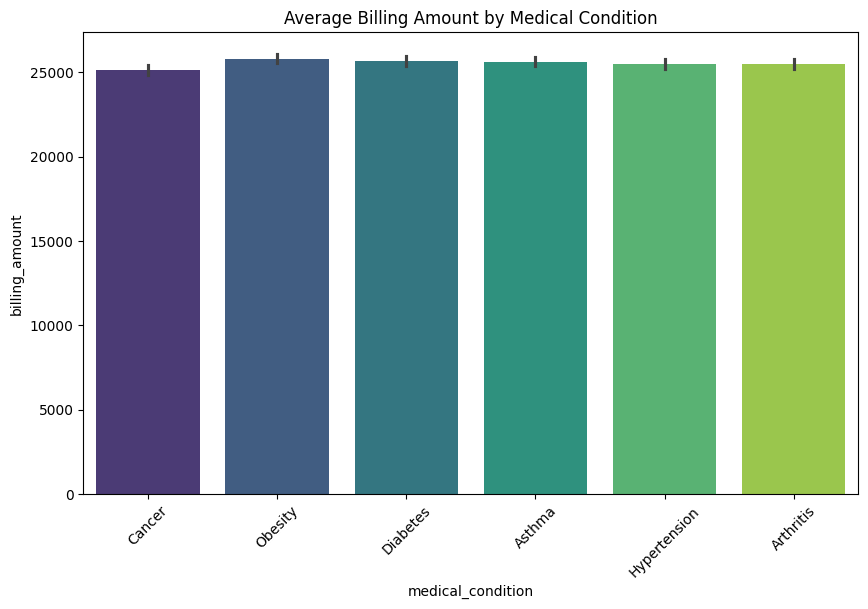

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=df, x='medical_condition', y='billing_amount', estimator='mean', palette='viridis')
plt.title('Average Billing Amount by Medical Condition')
plt.xticks(rotation=45)
plt.show()

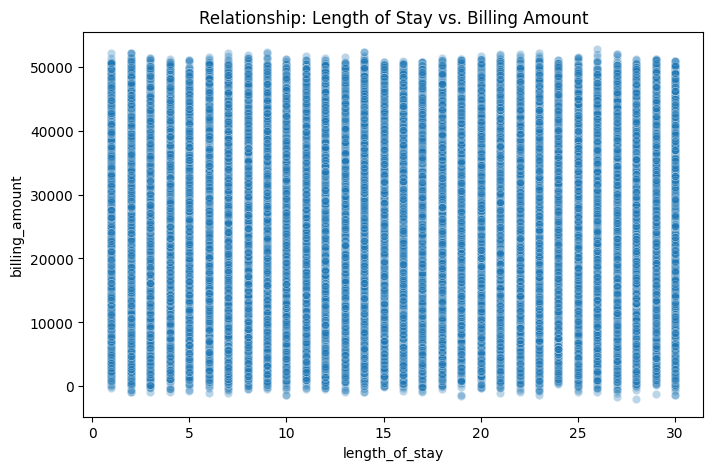

In [ ]:
# Does a longer stay mean a higher bill? (Correlation)
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='length_of_stay', y='billing_amount', alpha=0.3)
plt.title('Relationship: Length of Stay vs. Billing Amount')
plt.show()

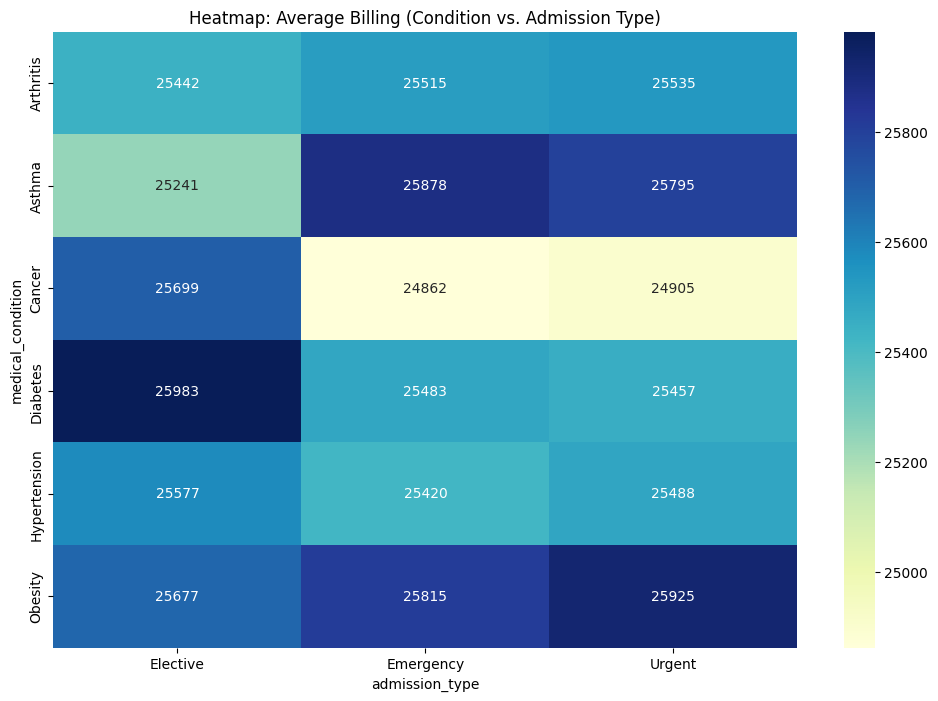

In [ ]:
# Create a pivot table for the heatmap
pivot = df.pivot_table(index='medical_condition', columns='admission_type', values='billing_amount', aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Heatmap: Average Billing (Condition vs. Admission Type)')
plt.show()